In [63]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [64]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder=StateGraph(State)

In [65]:
graph_builder

In [66]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [67]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [68]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7f0d2da59e50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f0d2da5a850>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [69]:
## Node functionallity 
def chatbot(state : State):
    return {"messages":[llm.invoke(state["messages"])]}


In [70]:
graph_builder=StateGraph(State)
graph_builder.add_node("llmchatbot", chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile graph 
graph=graph_builder.compile()

In [71]:
## visualize the graph 
from pathlib import Path

graph_png = graph.get_graph().draw_mermaid_png()

Path("graph.png").write_bytes(graph_png)



6443

In [72]:
response = graph.invoke({"messages":"Hi"})

In [73]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [74]:
for event in graph.stream({"messages":"Hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


# Bot with tool 

In [75]:
from langchain_tavily import TavilySearch

search_tool=TavilySearch(max_results=2)
search_tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [76]:
from langchain_core.tools import tool

## Custom function 
@tool
def multiply(a: int , b: int)-> int:
    """multiply a and b 
    
    Args:
        a (int): first int 
        b (int): second int
    Returns:
        int: output int 
    """
    return a *b 

In [77]:
tools=[search_tool,multiply]

In [78]:
llm_with_tool=llm.bind_tools(tools)

In [79]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode ,tools_condition

## Node Definition 
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                               tools_condition
                               )
builder.add_edge("tools", END)
graph = builder.compile()

graph_png = graph.get_graph().draw_mermaid_png()

Path("graph.png").write_bytes(graph_png)

9897

In [80]:
response = graph.invoke({"messages": "What is the recent ai news"})

In [81]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.consultancy.eu/news/amp/14046/europe-moves-forward-in-ai-race-but-maturity-is-uneven-and-gaps-remain", "title": "Europe moves forward in AI race, but maturity is uneven and gaps remain - Consultancy.eu", "score": 0.6636041, "published_date": "Wed, 08 Jul 2026 14:34:00 GMT", "content": "Last year’s Paris AI Summit in February appears to have been a major wake-up call for European leaders and the regional tech sector. In the most memorable speech at the summit, US Vice President JD Vance sharply criticized European regulations and essentially pronounced an American victory in the AI arms race. European governments have in recent years been working harder than ever before on independence from American tech, as concerns grow over increasingly strained trans-Atlantic relationships.\\n\\nWeighing in on the progress Europe has made in AI readiness, Gavin Stephenson, Accentu

In [82]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9mxe1ymgn)
 Call ID: 9mxe1ymgn
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.consultancy.eu/news/amp/14046/europe-moves-forward-in-ai-race-but-maturity-is-uneven-and-gaps-remain", "title": "Europe moves forward in AI race, but maturity is uneven and gaps remain - Consultancy.eu", "score": 0.6636041, "published_date": "Wed, 08 Jul 2026 14:34:00 GMT", "content": "Last year’s Paris AI Summit in February appears to have been a major wake-up call for European leaders and the regional tech sector. In the most

In [83]:
response = graph.invoke({"messages":"What is 2 mulitplied by 3"})

In [84]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 mulitplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (kqfcw5f43)
 Call ID: kqfcw5f43
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [85]:
response = graph.invoke({"messages":"What is 2 mulitplied by 3 then mulitply by  2 "})

In [86]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 mulitplied by 3 then mulitply by  2 
================================== Ai Message ==================================
Tool Calls:
  multiply (rge10jfpw)
 Call ID: rge10jfpw
  Args:
    a: 2
    b: 3
  multiply (th1k572ff)
 Call ID: th1k572ff
  Args:
    a: 6
    b: 2
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: multiply

12


In [88]:
response = graph.invoke({"messages":"What are the latest ai newses and then multiply 5 by 10 "})

In [ ]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the latest ai newses and then multiply 5 by 10 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (e72cw1rp6)
 Call ID: e72cw1rp6
  Args:
    query: latest AI news
    topic: news
  multiply (v5828c40t)
 Call ID: v5828c40t
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.7306941, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human oversight, while 

In [89]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode ,tools_condition

## Node Definition 
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                               tools_condition
                               )
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile()

graph_png = graph.get_graph().draw_mermaid_png()

Path("graph.png").write_bytes(graph_png)

10020

In [90]:
response = graph.invoke({"messages":"What are the latest ai newses and then multiply 5 by 10 "})

In [91]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the latest ai newses and then multiply 5 by 10 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (mq37qpg9f)
 Call ID: mq37qpg9f
  Args:
    query: latest ai news
    topic: news
  multiply (bctsymbk3)
 Call ID: bctsymbk3
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "latest ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-american-manufacturer-says-ai-creating-jobs-not-replacing-them", "title": "Newsletter: AI is creating jobs, not replacing them, manufacturer says - Fox News", "score": 0.72814995, "published_date": "Thu, 02 Jul 2026 17:17:28 GMT", "content": "Market data provided by Factset. * #### The trick to smoother streaming at home and on the road. * #### 

# Adding memory 

In [92]:
response = graph.invoke({"messages":"My name is bilal "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My name is bilal 
================================== Ai Message ==================================

Hello Bilal, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [93]:
response = graph.invoke({"messages":"What is my name "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name 
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


In [101]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode ,tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() # in memory checko=point saver 

## Node Definition 
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                               tools_condition
                               )
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile(checkpointer=memory)

graph_png = graph.get_graph().draw_mermaid_png()

Path("graph.png").write_bytes(graph_png)

10020

In [102]:
config={"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":"Hi my name is bilal"},config=config )
response

{'messages': [HumanMessage(content='Hi my name is bilal', additional_kwargs={}, response_metadata={}, id='9e765e77-38a5-4c85-9d22-4217603c94b3'),
  AIMessage(content="Hello Bilal, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1798, 'total_tokens': 1825, 'completion_time': 0.077373073, 'completion_tokens_details': None, 'prompt_time': 0.09251721, 'prompt_tokens_details': None, 'queue_time': 0.052692648, 'total_time': 0.169890283}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4565-1ea3-7400-92e4-3cb3583c4674-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1798, 'output_tokens': 27, 'total_tokens': 1825})]}

In [103]:
response["messages"][-1]

AIMessage(content="Hello Bilal, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1798, 'total_tokens': 1825, 'completion_time': 0.077373073, 'completion_tokens_details': None, 'prompt_time': 0.09251721, 'prompt_tokens_details': None, 'queue_time': 0.052692648, 'total_time': 0.169890283}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4565-1ea3-7400-92e4-3cb3583c4674-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1798, 'output_tokens': 27, 'total_tokens': 1825})

In [104]:
response = graph.invoke({"messages":"Hi What is my name"},config=config )
response

{'messages': [HumanMessage(content='Hi my name is bilal', additional_kwargs={}, response_metadata={}, id='9e765e77-38a5-4c85-9d22-4217603c94b3'),
  AIMessage(content="Hello Bilal, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1798, 'total_tokens': 1825, 'completion_time': 0.077373073, 'completion_tokens_details': None, 'prompt_time': 0.09251721, 'prompt_tokens_details': None, 'queue_time': 0.052692648, 'total_time': 0.169890283}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4565-1ea3-7400-92e4-3cb3583c4674-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1798, 'output_tokens': 27, 'total_tokens': 1825}),
  HumanMessage(content='Hi What is my name', additional_kwargs={}, re

In [105]:
response["messages"][-1].content

'Your name is Bilal.'

# Streaming 

In [106]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [107]:
def superbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [110]:
graph = StateGraph(State)

graph.add_node("Superbot", superbot)
graph.add_edge(START, "Superbot")

graph_builder = graph.compile(checkpointer=memory)

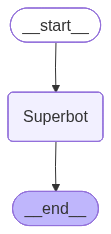

In [111]:
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
config= {"configurable": {"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi my name is bilal and i dont like cricket"}, config)

{'messages': [HumanMessage(content='Hi my name is bilal and i dont like cricket', additional_kwargs={}, response_metadata={}, id='783689a9-30a5-4b2c-b3df-e414abd9086c'),
  AIMessage(content="Nice to meet you, Bilal! Don't worry, not everyone has to be a cricket fan. There are plenty of other exciting sports and activities out there. What do you enjoy doing in your free time? Are you into any other sports, or do you have a different hobby or interest? I'm here to chat and get to know you better!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 46, 'total_tokens': 119, 'completion_time': 0.194638149, 'completion_tokens_details': None, 'prompt_time': 0.004433261, 'prompt_tokens_details': None, 'queue_time': 0.161589187, 'total_time': 0.19907141}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019

In [114]:
config = {"configurable": {"thread_id":"1"}}
for chunk in graph_builder.stream({"messages": "Hi, My name is Bilal and i dont like cricker"}, config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hi Bilal, nice to meet you again! Don't worry, no cricket talk here. So, what do you like to do for fun? Are you into music, movies, reading, or something else? Let's chat about something you enjoy!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 141, 'total_tokens': 193, 'completion_time': 0.165278105, 'completion_tokens_details': None, 'prompt_time': 0.01624932, 'prompt_tokens_details': None, 'queue_time': 0.401622225, 'total_time': 0.181527425}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4580-0f42-79d1-849d-5d37d090fc2f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 141, 'output_tokens': 52, 'total_tokens': 193})]}}


In [115]:
for chunk in graph_builder.stream({"messages": "Hi, My name is Bilal and i dont like cricker"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is bilal and i dont like cricket', additional_kwargs={}, response_metadata={}, id='783689a9-30a5-4b2c-b3df-e414abd9086c'), AIMessage(content="Nice to meet you, Bilal! Don't worry, not everyone has to be a cricket fan. There are plenty of other exciting sports and activities out there. What do you enjoy doing in your free time? Are you into any other sports, or do you have a different hobby or interest? I'm here to chat and get to know you better!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 46, 'total_tokens': 119, 'completion_time': 0.194638149, 'completion_tokens_details': None, 'prompt_time': 0.004433261, 'prompt_tokens_details': None, 'queue_time': 0.161589187, 'total_time': 0.19907141}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4

In [116]:
config = {"configurable": {"thread_id":"2"}}
for chunk in graph_builder.stream({"messages": "Hi, My name is Bilal and i dont like cricker"}, config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Bilal! Don't worry, not everyone has to like cricket. There are plenty of other sports and activities to enjoy. What do you like to do in your free time? Do you have any favorite hobbies or sports that you're passionate about?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 48, 'total_tokens': 104, 'completion_time': 0.158692021, 'completion_tokens_details': None, 'prompt_time': 0.001807205, 'prompt_tokens_details': None, 'queue_time': 0.059289864, 'total_time': 0.160499226}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4583-7a27-7492-a13d-7fcedaba6da1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 56, 'total_tokens': 104})]}}


In [117]:
for chunk in graph_builder.stream({"messages": "i dont like football too "}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Bilal and i dont like cricker', additional_kwargs={}, response_metadata={}, id='5068e77c-b297-477e-b64c-fd7046e6907f'), AIMessage(content="Nice to meet you, Bilal! Don't worry, not everyone has to like cricket. There are plenty of other sports and activities to enjoy. What do you like to do in your free time? Do you have any favorite hobbies or sports that you're passionate about?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 48, 'total_tokens': 104, 'completion_time': 0.158692021, 'completion_tokens_details': None, 'prompt_time': 0.001807205, 'prompt_tokens_details': None, 'queue_time': 0.059289864, 'total_time': 0.160499226}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4583-7a27-7492-a13d-7fcedaba6da1-0', tool_calls=[], invalid_too

In [120]:
config = {"configurable": {"thread_id":"4"}}
async for event  in graph_builder.astream_events({"messages": "Hi, My name is Bilal and i dont like cricker"}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Bilal and i dont like cricker'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f4588-3547-73e1-92b4-9123f95ba01b', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Bilal and i dont like cricker', additional_kwargs={}, response_metadata={}, id='15aabd9d-9932-4a56-a900-d2133aa22147')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019f4588-354a-7870-a5bb-11b2ef4442c2', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:151902dd-5e44-b125-b7c7-01541e575668'}, 'parent_ids': ['019f4588-3547-73e1-92b4-9123f95ba01b']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[Hum

# Human in the loop